In [3]:
import sklearn as sk
import pandas as pd
import numpy as np
import requests
import io



In [4]:
from urllib.request import urlretrieve

medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x193095f42d0>)

In [5]:
medical_df = pd.read_csv('medical.csv')


In [6]:
#give info about the data type and size

medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
#gives the math details of the data

medical_df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
import plotly.express as px

px.scatter(medical_df, x='age', y='charges', color='smoker')

In [9]:
px.histogram(medical_df,x='age',nbins=20,color='smoker')

In [10]:
cov_matrix = medical_df[["age", "bmi", "children"]].corr()
print(cov_matrix)

               age       bmi  children
age       1.000000  0.109272  0.042469
bmi       0.109272  1.000000  0.012759
children  0.042469  0.012759  1.000000


In [11]:
fig =px.histogram(medical_df, x='age', color='region', marginal='box',nbins = 5)

fig.update_layout(bargap=0.1)

In [12]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
diagram = px.histogram(medical_df, x = 'bmi', marginal = 'box', nbins = 47)
diagram.update_layout(bargap=0.1)

In [14]:
graph = px.histogram(medical_df,x = 'charges', marginal = 'box', nbins = 50,color='smoker')
graph.update_layout(bargap=0.1)

In [15]:
medical_df[['age', 'bmi', 'children']].corr()

,age,bmi,children
age,1.000000,0.109272,0.042469
bmi,0.109272,1.000000,0.012759
children,0.042469,0.012759,1.000000


In [16]:
import pandasql as ps

query = "SELECT age, bmi, children FROM medical_df"
result = ps.sqldf(query)
print(result)

      age     bmi  children
0      19  27.900         0
1      18  33.770         1
2      28  33.000         3
3      33  22.705         0
4      32  28.880         0
...   ...     ...       ...
1333   50  30.970         3
1334   18  31.920         0
1335   18  36.850         0
1336   21  25.800         0
1337   61  29.070         0

[1338 rows x 3 columns]


In [17]:
query = "SELECT  * from medical_df where sex = 'female' "

In [18]:
import pandasql as ps

ps.sqldf(query)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92400
1,31,female,25.74,0,no,southeast,3756.62160
2,46,female,33.44,1,no,southeast,8240.58960
3,37,female,27.74,3,no,northwest,7281.50560
4,60,female,25.84,0,no,northwest,28923.13692
...,...,...,...,...,...,...,...
657,52,female,44.70,3,no,southwest,11411.68500
658,18,female,31.92,0,no,northeast,2205.98080
659,18,female,36.85,0,no,southeast,1629.83350
660,21,female,25.80,0,no,southwest,2007.94500


In [19]:
medical_test = medical_df

medical_test['sex']= medical_test['sex'].map({'male': 0, 'female': 1})

In [20]:
# for gender also the the prediction of charge is made using scikit learn



from sklearn.linear_model import LinearRegression

model = LinearRegression()

model_gender= model.fit(medical_test[['age','bmi','children','sex']], medical_test['charges'])

model_gender.predict([[61, 29.07, 0,0]])





c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([18077.78089505])

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model=model.fit(medical_df[['age', 'bmi', 'children']], medical_df['charges'])

model.predict([[61, 29.07, 0]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([17377.08299024])

In [22]:
medical_test

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



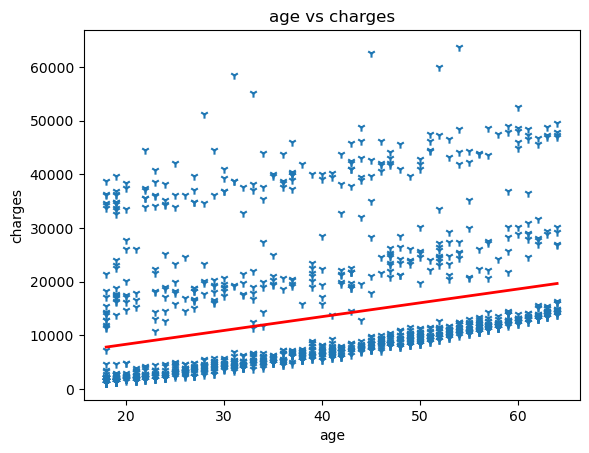

In [23]:
import matplotlib.pyplot as plt

plt.scatter(medical_df['age'],medical_df['charges'],marker='1')

plt.xlabel('age')
plt.ylabel('charges')

plt.title('age vs charges')


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model=model.fit(medical_df[['age']], medical_df['charges'])

x = [i for i in range(18,65)]
y = model.predict([[i] for i in x])
plt.plot(x, y, color='red', linewidth=2)


In [24]:



import plotly.express as px

px.scatter_3d(medical_df, x='age', y='bmi', z='charges')

In [25]:
model.coef_

array([257.72261867])

In [26]:
smoker_df = medical_df[medical_df['smoker'] == 'yes']

model_smoke = model.fit(smoker_df[['age', 'bmi', 'children']], smoker_df['charges'])


model_smoke.predict([[61, 29.07, 0]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([35428.69478336])

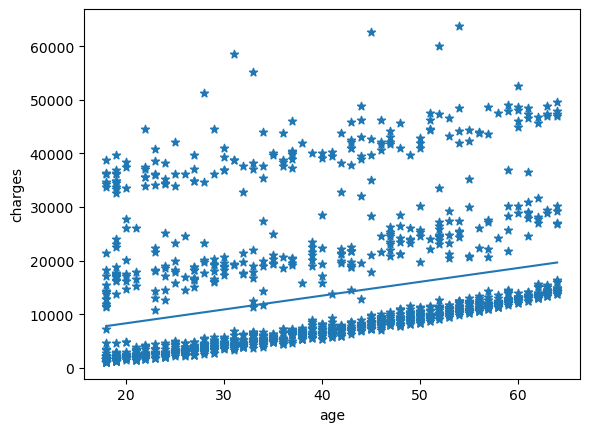

In [27]:
#this feature tells how the age vs charges changes just for interpretation and visualization purpose

from sklearn.linear_model import LinearRegression as sk



plt.scatter(medical_test['age'],medical_test['charges'],marker='*')

def prediction(m,c):

    x = [i for i in range(18,65)]
    eqn = [m * i + c for i in x]

    plt.plot(x, eqn, color='red', linewidth=2)

    plt.scatter(medical_test['age'],medical_test['charges'])
    plt.xlabel('age')
    plt.ylabel('charges')
    plt.title('age vs charges for self prediction ')


def linear_regression():

   

    model = LinearRegression()
    model_2=model.fit(medical_test['age'].values.reshape(-1,1),medical_test['charges'])
    w = model_2.coef_
    b = model_2.intercept_
    

    x = [i for i in range(medical_test['age'].min(),medical_test['age'].max()+1)]
    y = w * x + b

    plt.plot(x,y)
    plt.xlabel('age')
    plt.ylabel('charges')


linear_regression()

#prediction(300,500)

In [28]:
from sklearn.model_selection import train_test_split as test

from sklearn.linear_model import LinearRegression as LR

temp = test(medical_test['age'],medical_test['charges'])


model_Linear = LR().fit(temp[0].values.reshape(-1,1), temp[2])

prediction_test = model_Linear.predict(medical_test['age'].values.reshape(-1,1))

prediction_test



array([ 8040.09291308,  7778.91215535, 10390.71973264, ...,
        7778.91215535,  8562.45442854, 19009.68473771], shape=(1338,))

In [ ]:
try:
    import sys
    del sys.modules["helper_functions"]
except:
    pass


from helper_functions import Linear_Regression as LRE


num = LRE().mse(medical_test['age'], )


print(num)

del(num)


0.0


In [ ]:
from sklearn.linear_model import LinearRegression as LR

model_predict = LR().fit(X=medical_test[['bmi','children']] , y = medical_test['charges'] )

predicted = model_predict.predict(medical_test[['bmi', 'children']])

try:
    import sys
    del sys.modules["helper_functions"]
except:
    pass


from helper_functions import Linear_Regression as LRE


num = LRE().mse(medical_test['charges'], predicted)


print(num)

del(num)


11837.55762615908


In [61]:
from sklearn.linear_model import LogisticRegression as LLR


model_LLR = LLR()

result = model_LLR.fit(X=medical_test[['bmi','children']] , y = medical_test['smoker'])


import matplotlib.pyplot as plt

x = result.predict(X = medical_test[['bmi','children']])
y = medical_test['smoker']





In [53]:
medical_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 73.3+ KB
